In [16]:
import pandas as pd

In [17]:
cnts = pd.read_csv('read-counts.txt', sep='\t', comment='#', index_col=0)

In [18]:
cnts.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,CLIP-let7g.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam
Geneid,,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0,0
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0,0
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,0,1,1,1,0,0
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0,0
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0,0


In [19]:
cnts['clip_enrichment'] = cnts['CLIP-35L33G.bam'] / cnts['RNA-control.bam']
cnts['rden_change'] = (cnts['RPF-siLin28a.bam'] / cnts['RNA-siLin28a.bam']) / (cnts['RPF-siLuc.bam'] / cnts['RNA-siLuc.bam'])

In [20]:
cnts.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,CLIP-let7g.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam,clip_enrichment,rden_change
Geneid,,,,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0,0,NaN,NaN
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0,0,NaN,NaN
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,0,1,1,1,0,0,4.0,NaN
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0,0,inf,NaN
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0,0,NaN,NaN


In [21]:
from matplotlib import pyplot as plt
import numpy as np

/home/jobor/miniconda3/envs/binfo1/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


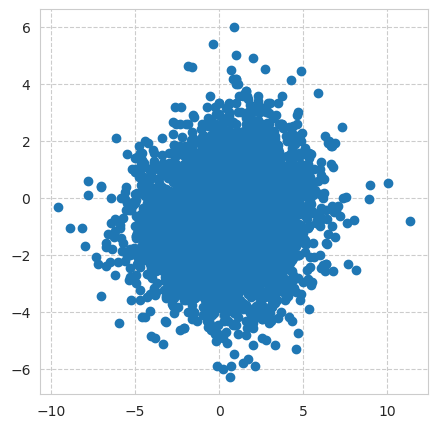

In [22]:
fig, ax =plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(np.log2(cnts['clip_enrichment']),
           np.log2(cnts['rden_change']))

In [23]:
import numpy as np

cnts['clip_enrichment'] = np.log2((cnts['CLIP-35L33G.bam'] + 1) / (cnts['RNA-control.bam'] + 1))

rden_siLin28a = (cnts['RPF-siLin28a.bam'] + 1) / (cnts['RNA-siLin28a.bam'] + 1)
rden_siLuc = (cnts['RPF-siLuc.bam'] + 1) / (cnts['RNA-siLuc.bam'] + 1)
cnts['rden_change'] = np.log2(rden_siLin28a / rden_siLuc)

/home/jobor/miniconda3/envs/binfo1/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/jobor/miniconda3/envs/binfo1/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


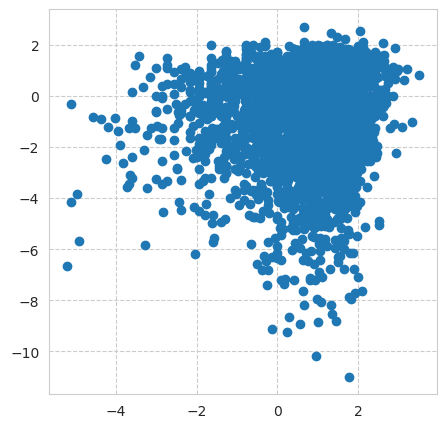

In [24]:
fig, ax =plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(np.log2(cnts['clip_enrichment']),
           np.log2(cnts['rden_change']))

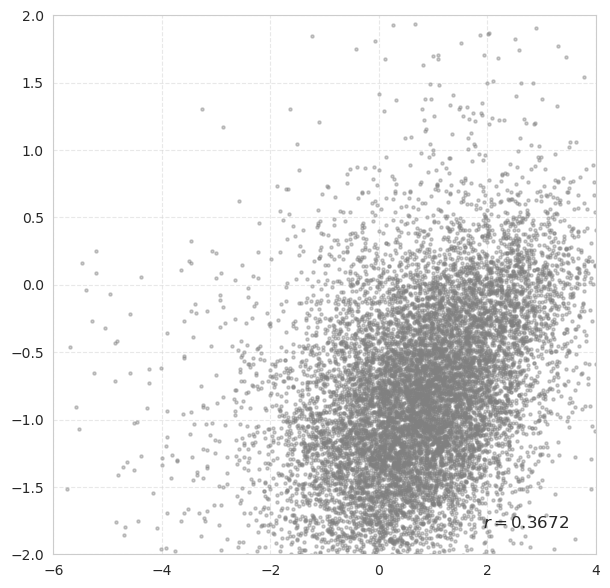

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


expression_mask = (
    cnts['RPF-siLin28a.bam'] + cnts['RNA-siLin28a.bam'] + 
    cnts['RPF-siLuc.bam'] + cnts['RNA-siLuc.bam']
) > 100

df_clean = cnts[expression_mask].copy()

df_clean['x_val'] = np.log2((df_clean['CLIP-35L33G.bam'] + 1) / (df_clean['RNA-control.bam'] + 1))

rden_exp = (df_clean['RPF-siLin28a.bam'] + 1) / (df_clean['RNA-siLin28a.bam'] + 1)
rden_ctrl = (df_clean['RPF-siLuc.bam'] + 1) / (df_clean['RNA-siLuc.bam'] + 1)
df_clean['y_val'] = np.log2(rden_exp / rden_ctrl)


fig, ax = plt.subplots(figsize=(7, 7))


ax.scatter(df_clean['x_val'], df_clean['y_val'], color='grey', s=5, alpha=0.4)

ax.set_xlim(-6, 4)
ax.set_ylim(-2, 2)
ax.grid(color='lightgrey', linestyle='--', alpha=0.5)

r_val, _ = pearsonr(df_clean['x_val'], df_clean['y_val'])
ax.text(0.95, 0.05, f'$r = {r_val:.4f}$', transform=ax.transAxes, ha='right', fontsize=12)

plt.show()

In [26]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mouselocal = pd.read_csv('https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt', sep='\t')
mouselocal.head()

,gene_id,Gene names,type
0,ENSMUSG00000000001,Gnai3,cytoplasm
1,ENSMUSG00000000028,Cdc45 Cdc45l Cdc45l2,nucleus
2,ENSMUSG00000000049,Apoh B2gp1,cytoplasm
3,ENSMUSG00000000058,Cav2,cytoplasm
4,ENSMUSG00000000085,Scmh1,nucleus


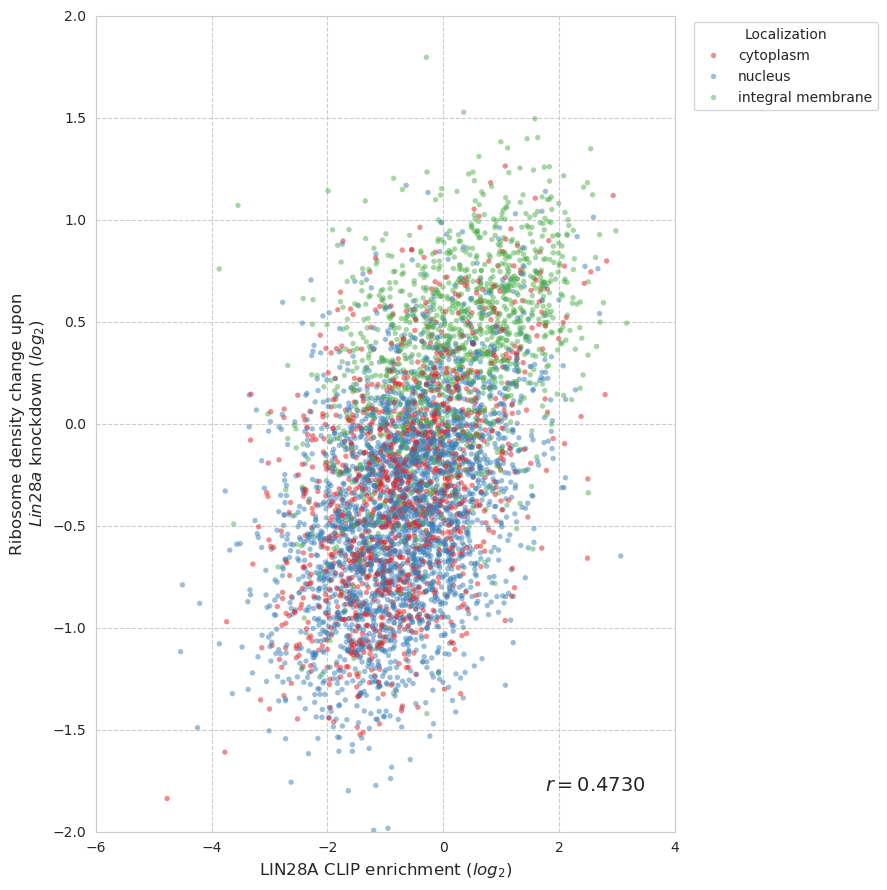

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import ssl

cnts = pd.read_csv('read-counts.txt', sep='\t', comment='#', index_col=0)

sample_cols = [
    'CLIP-35L33G.bam', 'RNA-control.bam', 
    'RNA-siLin28a.bam', 'RNA-siLuc.bam', 
    'RPF-siLin28a.bam', 'RPF-siLuc.bam'
]

total_reads = cnts[sample_cols].sum()
cnts_norm = (cnts[sample_cols] / total_reads) * 1_000_000

strict_mask = (cnts_norm > 2.0).all(axis=1)
df = cnts_norm[strict_mask].copy()

df['x_val'] = np.log2((df['CLIP-35L33G.bam'] + 1) / (df['RNA-control.bam'] + 1))

rden_exp = (df['RPF-siLin28a.bam'] + 1) / (df['RNA-siLin28a.bam'] + 1)
rden_ctrl = (df['RPF-siLuc.bam'] + 1) / (df['RNA-siLuc.bam'] + 1)
df['y_val'] = np.log2(rden_exp / rden_ctrl)

df.index = df.index.str.replace(r'\.\d+', '', regex=True)

ssl._create_default_https_context = ssl._create_unverified_context
mouselocal = pd.read_csv('https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt', sep='\t')

final_df = pd.merge(df, mouselocal, left_index=True, right_on='gene_id', how='left')

plt.figure(figsize=(9, 9))
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.scatterplot(data=final_df, x='x_val', y='y_val', hue='type', 
                palette='Set1', s=15, alpha=0.5, edgecolors='none')

plt.xlim(-6, 4)
plt.ylim(-2, 2)
plt.xlabel('LIN28A CLIP enrichment ($log_2$)', fontsize=12)
plt.ylabel('Ribosome density change upon\n$Lin28a$ knockdown ($log_2$)', fontsize=12)

clean_data = final_df[['x_val', 'y_val']].dropna()
r_val, _ = pearsonr(clean_data['x_val'], clean_data['y_val'])
plt.text(0.95, 0.05, f'$r = {r_val:.4f}$', transform=plt.gca().transAxes, 
         ha='right', fontsize=14, fontweight='bold')

plt.legend(title='Localization', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()